In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
ts = pd.read_csv("data\Microsoft_Stock.csv")
ts.head()

,Date,Open,High,Low,Close,Volume
0,4/1/2015 16:00:00,40.60,40.76,40.31,40.72,36865322
1,4/2/2015 16:00:00,40.66,40.74,40.12,40.29,37487476
2,4/6/2015 16:00:00,40.34,41.78,40.18,41.55,39223692
3,4/7/2015 16:00:00,41.61,41.91,41.31,41.53,28809375
4,4/8/2015 16:00:00,41.48,41.69,41.04,41.42,24753438


In [5]:
# Train test Split
train_size = int(len(ts) * 0.8)

train = ts['Close'][:train_size]
test = ts['Close'][train_size:]

In [6]:
from statsmodels.tsa.arima.model import ARIMA

history = list(train)
predictions = []

for t in range(len(test)):

    model = ARIMA(history, order=(1,1,1))
    model_fit = model.fit()

    yhat = model_fit.forecast()[0]
    predictions.append(yhat)

    history.append(test.iloc[t])

In [7]:
from sklearn.metrics import mean_squared_error
import numpy as np

rmse = np.sqrt(mean_squared_error(test, predictions))
print("RMSE:", rmse)

RMSE: 4.485278664341516


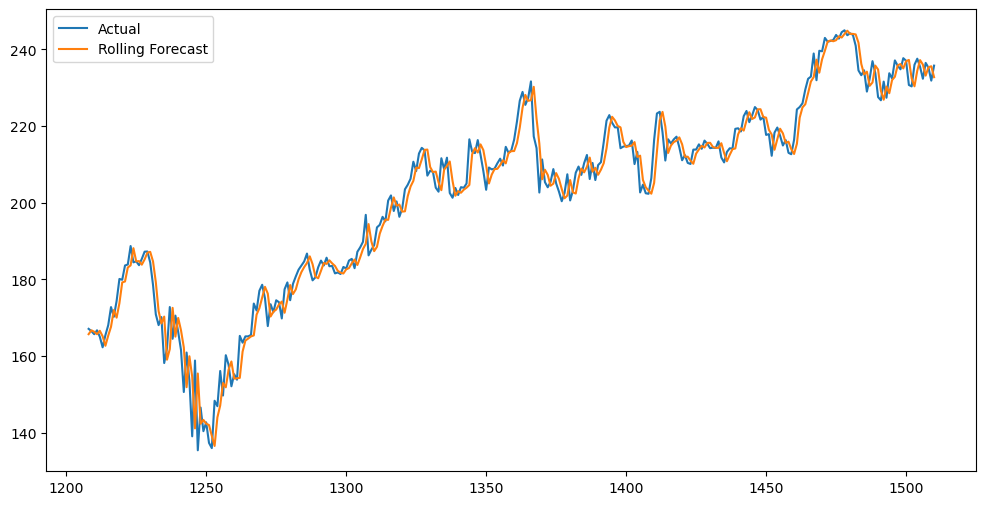

In [8]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, predictions, label='Rolling Forecast')
plt.legend()
plt.show()

In [9]:
# ARIMA orders planned for comparison (p, d, q)
orders_to_try = [(0, 1, 1), (1, 1, 0), (1, 1, 1), (2, 1, 1), (1, 1, 2)]
orders_to_try

[(0, 1, 1), (1, 1, 0), (1, 1, 1), (2, 1, 1), (1, 1, 2)]

In [10]:
from statsmodels.tsa.arima.model import ARIMA

history = list(train)
predictions1 = []

for t in range(len(test)):

    model1 = ARIMA(history, order=(0,1,1))
    model_fit1 = model1.fit()

    yhat1 = model_fit1.forecast()[0]
    predictions1.append(yhat1)

    history.append(test.iloc[t])

In [11]:
rmse1 = np.sqrt(mean_squared_error(test, predictions1))
print("RMSE:", rmse1)

RMSE: 4.477367500466411


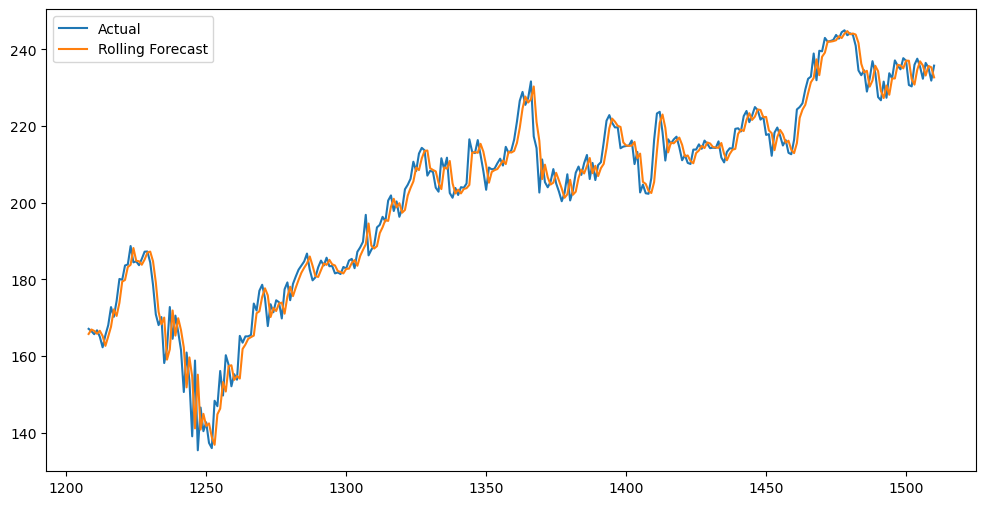

In [12]:
plt.figure(figsize=(12,6))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, predictions1, label='Rolling Forecast')
plt.legend()
plt.show()

In [13]:
history = list(train)
predictions2 = []

for t in range(len(test)):

    model2 = ARIMA(history, order=(1,1,0))
    model_fit2 = model2.fit()

    yhat2 = model_fit2.forecast()[0]
    predictions2.append(yhat2)

    history.append(test.iloc[t])

In [14]:
rmse2 = np.sqrt(mean_squared_error(test, predictions2))
print("RMSE:", rmse2)

RMSE: 4.464072917250501


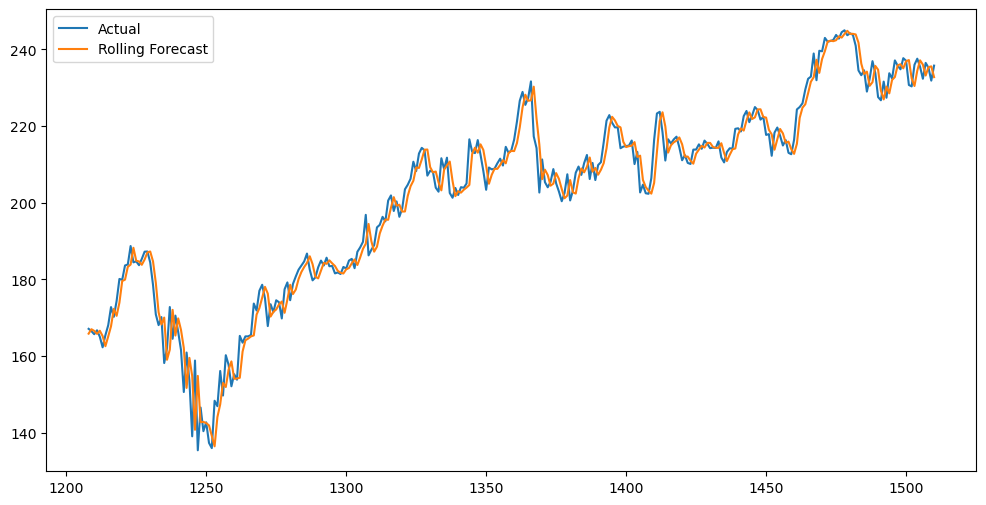

In [15]:
plt.figure(figsize=(12,6))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, predictions2, label='Rolling Forecast')
plt.legend()
plt.show()

In [16]:
history = list(train)
predictions3 = []

for t in range(len(test)):

    model3 = ARIMA(history, order=(2,1,1))
    model_fit3 = model3.fit()

    yhat3 = model_fit3.forecast()[0]
    predictions3.append(yhat3)

    history.append(test.iloc[t])

c:\Users\Asus\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:966: UserWarning: Non-stationary starting autoregressive parameters found. Using zeros as starting parameters.
  warn('Non-stationary starting autoregressive parameters'
c:\Users\Asus\anaconda3\Lib\site-packages\statsmodels\tsa\statespace\sarimax.py:978: UserWarning: Non-invertible starting MA parameters found. Using zeros as starting parameters.
  warn('Non-invertible starting MA parameters found.'


In [17]:
rmse3 = np.sqrt(mean_squared_error(test, predictions3))
print("RMSE:", rmse3)

RMSE: 4.474178913692296


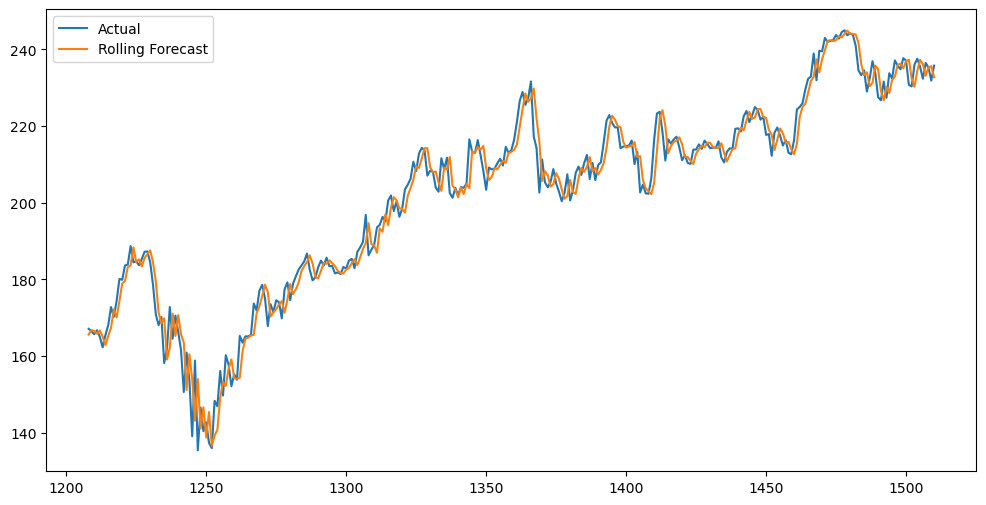

In [18]:
plt.figure(figsize=(12,6))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, predictions3, label='Rolling Forecast')
plt.legend()
plt.show()

In [19]:
history = list(train)
predictions4 = []

for t in range(len(test)):

    model4 = ARIMA(history, order=(1,1,2))
    model_fit4 = model4.fit()

    yhat4 = model_fit4.forecast()[0]
    predictions4.append(yhat4)

    history.append(test.iloc[t])

In [20]:
rmse4 = np.sqrt(mean_squared_error(test, predictions4))
print("RMSE:", rmse4)

RMSE: 4.477495651151309


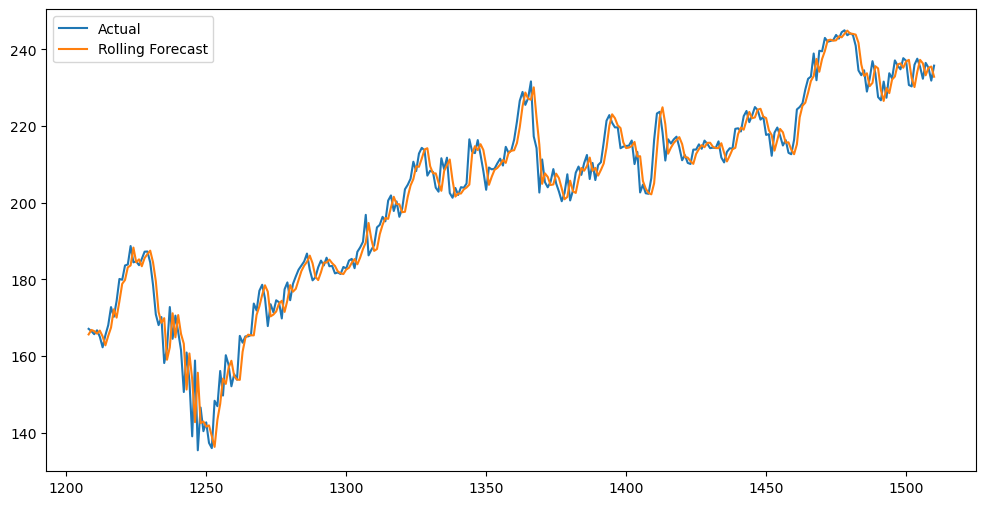

In [21]:
plt.figure(figsize=(12,6))
plt.plot(test.index, test, label='Actual')
plt.plot(test.index, predictions4, label='Rolling Forecast')
plt.legend()
plt.show()

In [22]:
results = {
    'ARIMA(1,1,1)': {'aic': model_fit.aic,  'rmse': rmse},
    'ARIMA(0,1,1)': {'aic': model_fit1.aic, 'rmse': rmse1},
    'ARIMA(1,1,0)': {'aic': model_fit2.aic, 'rmse': rmse2},
    'ARIMA(2,1,1)': {'aic': model_fit3.aic, 'rmse': rmse3},
    'ARIMA(1,1,2)': {'aic': model_fit4.aic, 'rmse': rmse4},
}

results_df = pd.DataFrame(results).T.sort_values('rmse')
print(results_df)

best_model_name = results_df.index[0]
print(f"\nBest model based on RMSE: {best_model_name}")

                      aic      rmse
ARIMA(1,1,0)  6761.035211  4.464073
ARIMA(2,1,1)  6764.306321  4.474179
ARIMA(0,1,1)  6771.995900  4.477368
ARIMA(1,1,2)  6761.272799  4.477496
ARIMA(1,1,1)  6762.965446  4.485279

Best model based on RMSE: ARIMA(1,1,0)


The best-performing model is selected programmatically above (lowest RMSE on the held-out test set, cross-checked against AIC) rather than assumed in advance.

In [23]:
model_lookup = {
    'ARIMA(1,1,1)': model_fit,
    'ARIMA(0,1,1)': model_fit1,
    'ARIMA(1,1,0)': model_fit2,
    'ARIMA(2,1,1)': model_fit3,
    'ARIMA(1,1,2)': model_fit4,
}

best_model = model_lookup[best_model_name]
future_values = best_model.forecast(30)
future_values

array([232.76462642, 232.51785902, 232.58443719, 232.56647431,
       232.57132072, 232.57001315, 232.57036593, 232.57027075,
       232.57029643, 232.5702895 , 232.57029137, 232.57029087,
       232.57029101, 232.57029097, 232.57029098, 232.57029098,
       232.57029098, 232.57029098, 232.57029098, 232.57029098,
       232.57029098, 232.57029098, 232.57029098, 232.57029098,
       232.57029098, 232.57029098, 232.57029098, 232.57029098,
       232.57029098, 232.57029098])

In [24]:
future_values

array([232.76462642, 232.51785902, 232.58443719, 232.56647431,
       232.57132072, 232.57001315, 232.57036593, 232.57027075,
       232.57029643, 232.5702895 , 232.57029137, 232.57029087,
       232.57029101, 232.57029097, 232.57029098, 232.57029098,
       232.57029098, 232.57029098, 232.57029098, 232.57029098,
       232.57029098, 232.57029098, 232.57029098, 232.57029098,
       232.57029098, 232.57029098, 232.57029098, 232.57029098,
       232.57029098, 232.57029098])